In this notebook we simulate future stock prices, risk-free rates, 3 year bonds and sharpe ratios from 31 october 2014 to 31 october 2033. We assume that the voatility follows stockastic process (Heston Model). We assume that other 

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import market_stochastic_simulation as mss
import retirement_client as pensioner

# 1. Market Simulation Code

$
\begin{cases}
r_{t+dt} = r_t + \kappa_r (\bar{lt_r} - r_t) dt + \sigma_r \sqrt{dt} Z_t^r\\
SR_{t+dt} = SR_t + \kappa_sr (\bar{lt_sr} - SR_t) dt + \sigma_SR \sqrt{dt} Z_t^SR\\
V_{t+dt} = V_t + \kappa_v (lt_V - V_t) dt + \sigma_V \sqrt{V_t} \sqrt{dt} Z_t^V\\
S_{t+dt} = S_t \times \exp \left( \left( r + \bar{\lambda_0} \sigma_t - \frac{1}{2} \sigma_t^2 \right) dt + \sigma_t \sqrt{dt} Z_t^S \right) \\
\end{cases}
$

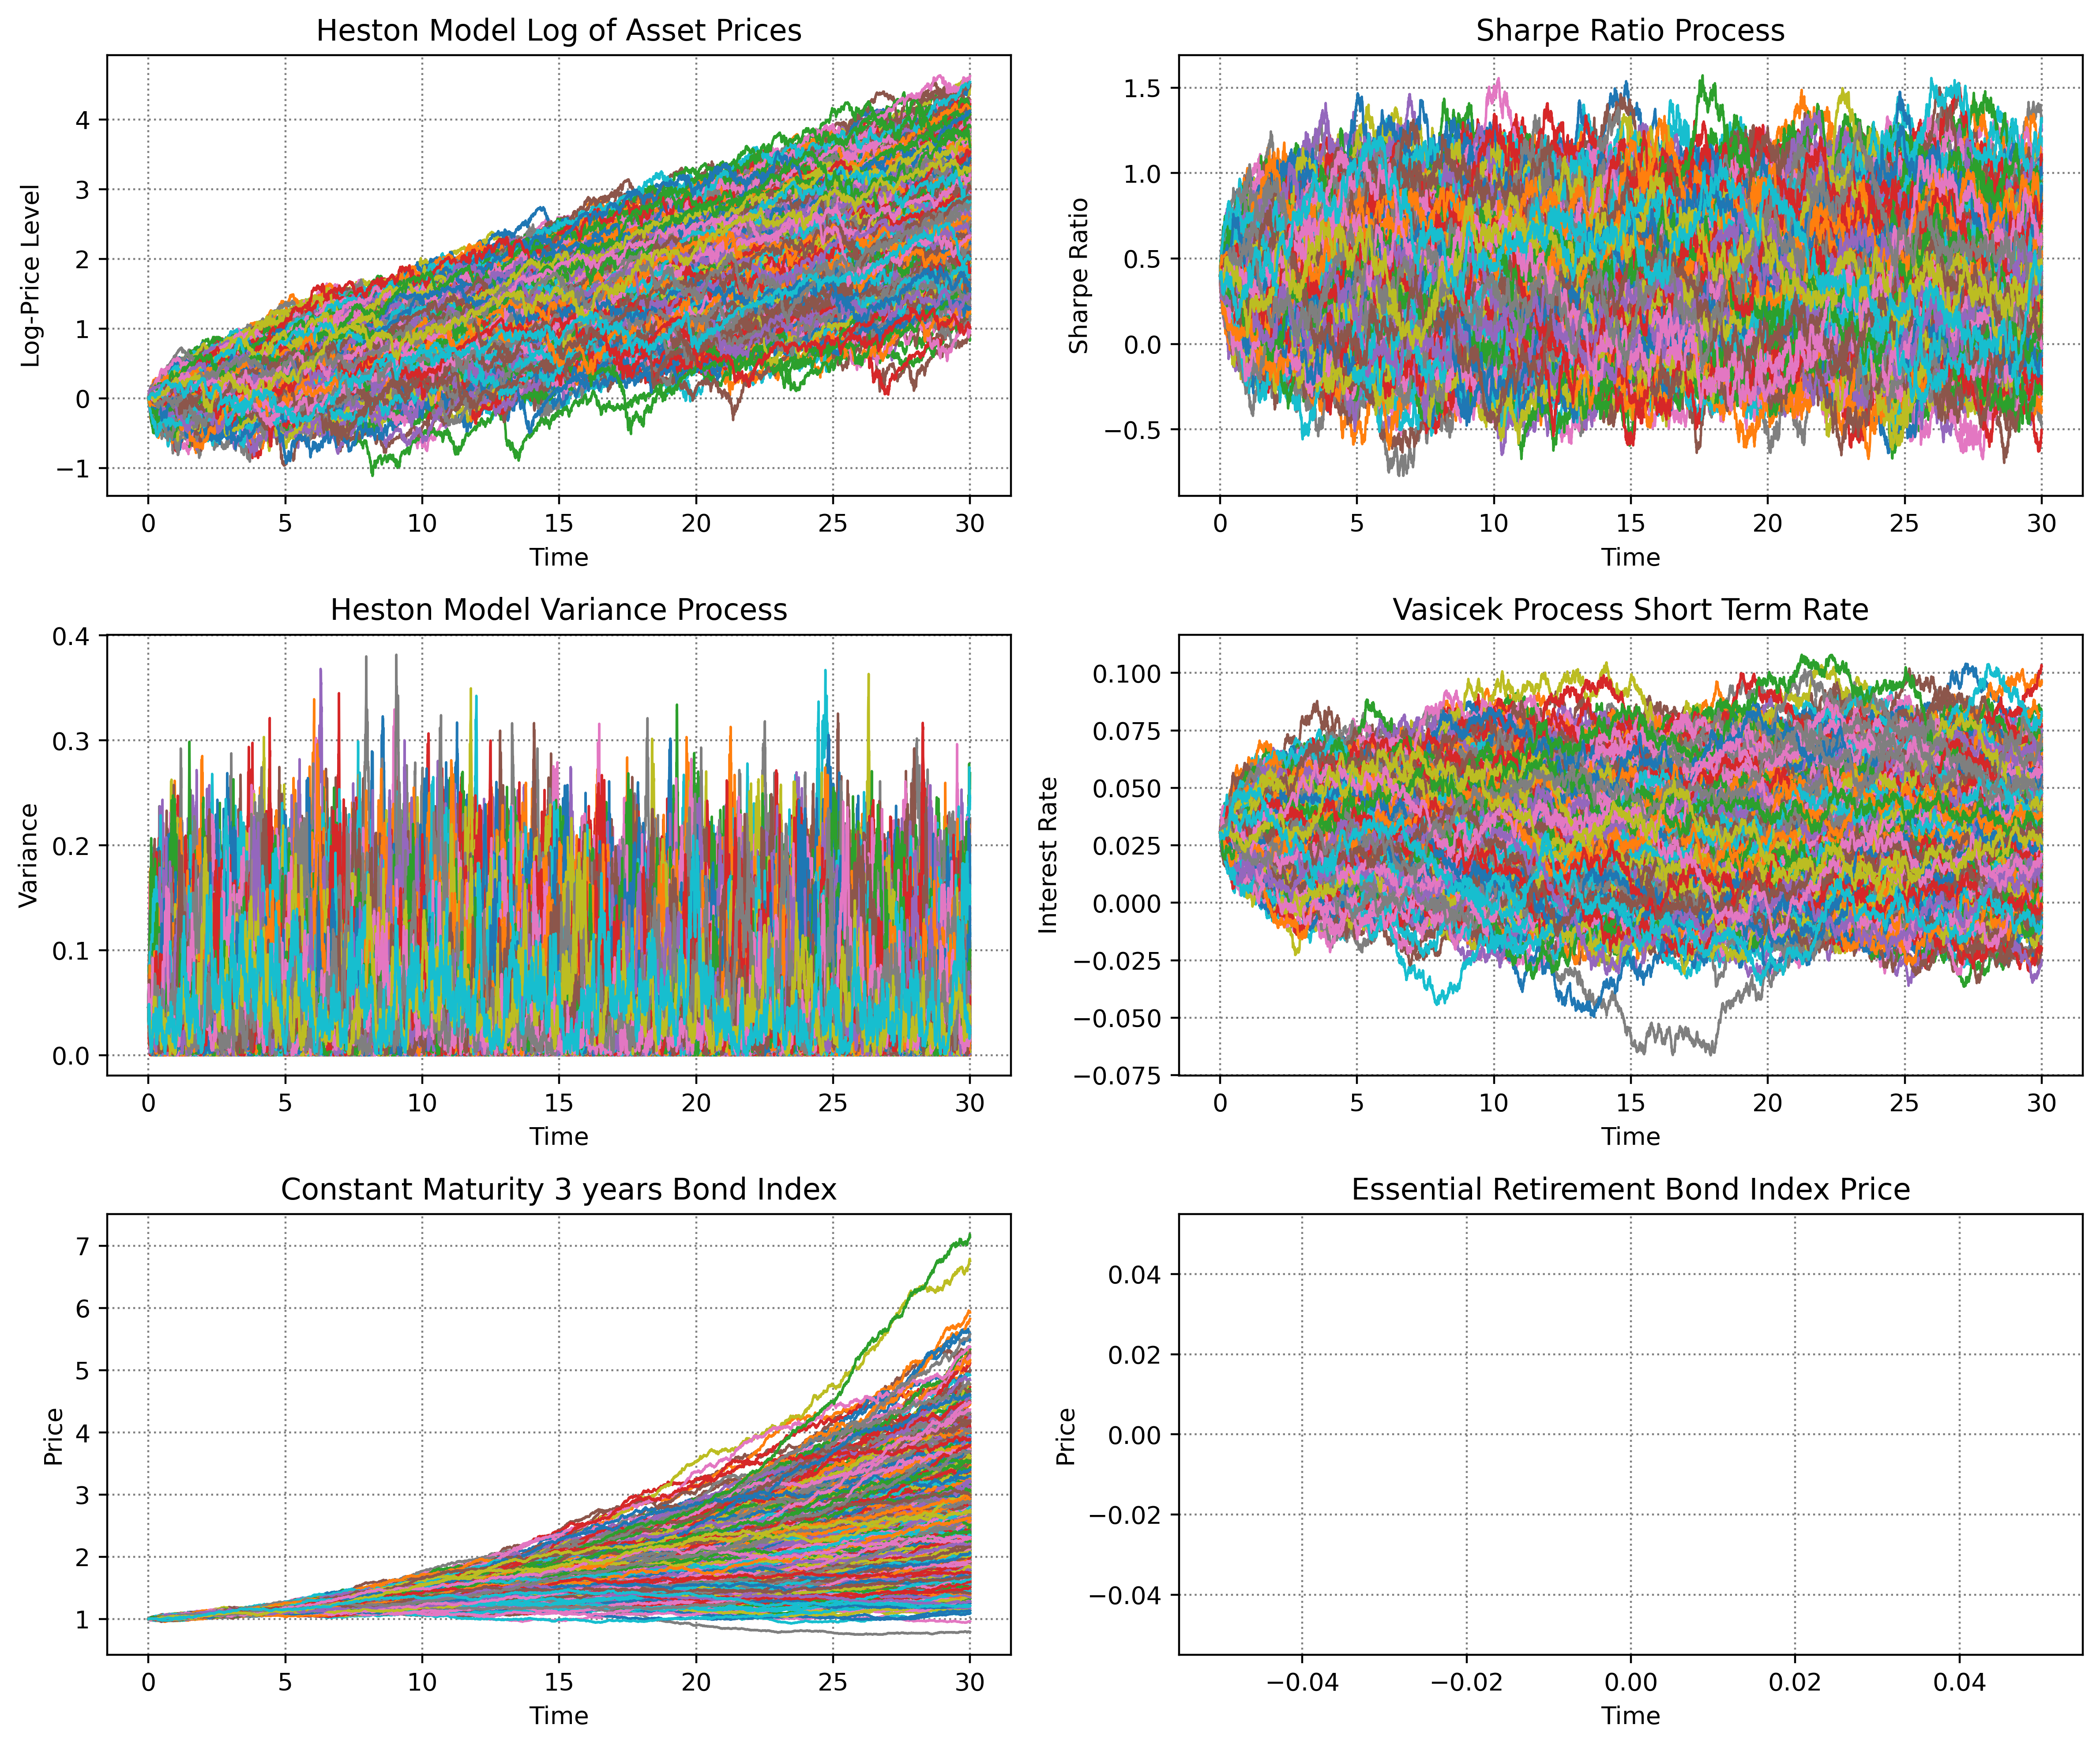

In [4]:
# Parameters
S0 = 1.0              # asset price
T = 30                  # time in years
N = 252*T              # number of time steps in simulation
M = 1000                # number of simulated paths
seed = 123              # simulation seed

simulated_market = mss.MarketSimulator(T,N,M,seed, S0)
simulated_market.plot_market_simulation(background_black=False, dpi = 400)

## Initialize client

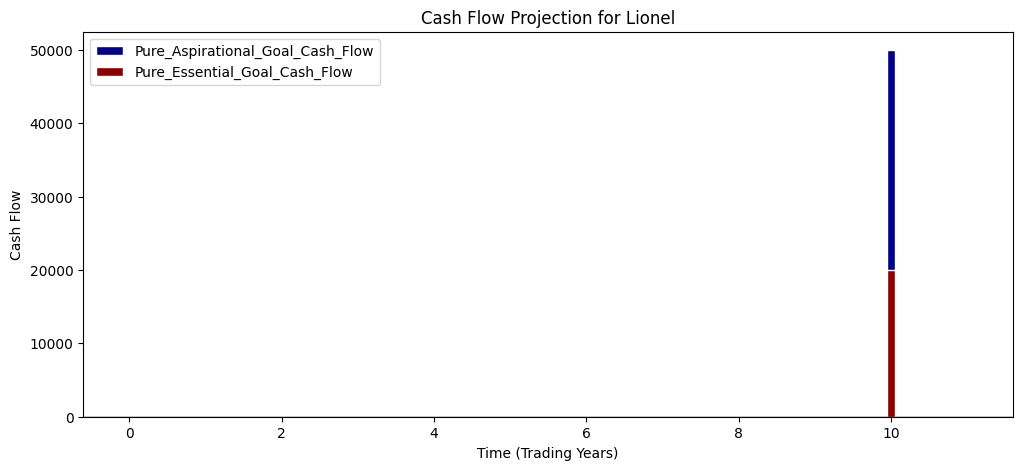

In [5]:
client = pensioner.RetirementClient("Lionel",
                           accumulation_years=10,
                           accumulation_cash_flow=0,
                           decumulation_years=1,
                           decumulation_cash_flow_essential=20000,
                           decumulation_cash_flow_aspirational=50000,
                           periodicity = 12,
                           inflation_rate = 0.00
                           )

client.plot_cash_flows()

In [6]:
df = client.cash_flows_df.loc[:,['Pure_Essential_Goal_Cash_Flow','Pure_Aspirational_Goal_Cash_Flow']]
df = df[df.Pure_Essential_Goal_Cash_Flow!=0]
#for i in np.arange(0,11,1):
#    df.loc[i,:] = 0
df = df.sort_index()

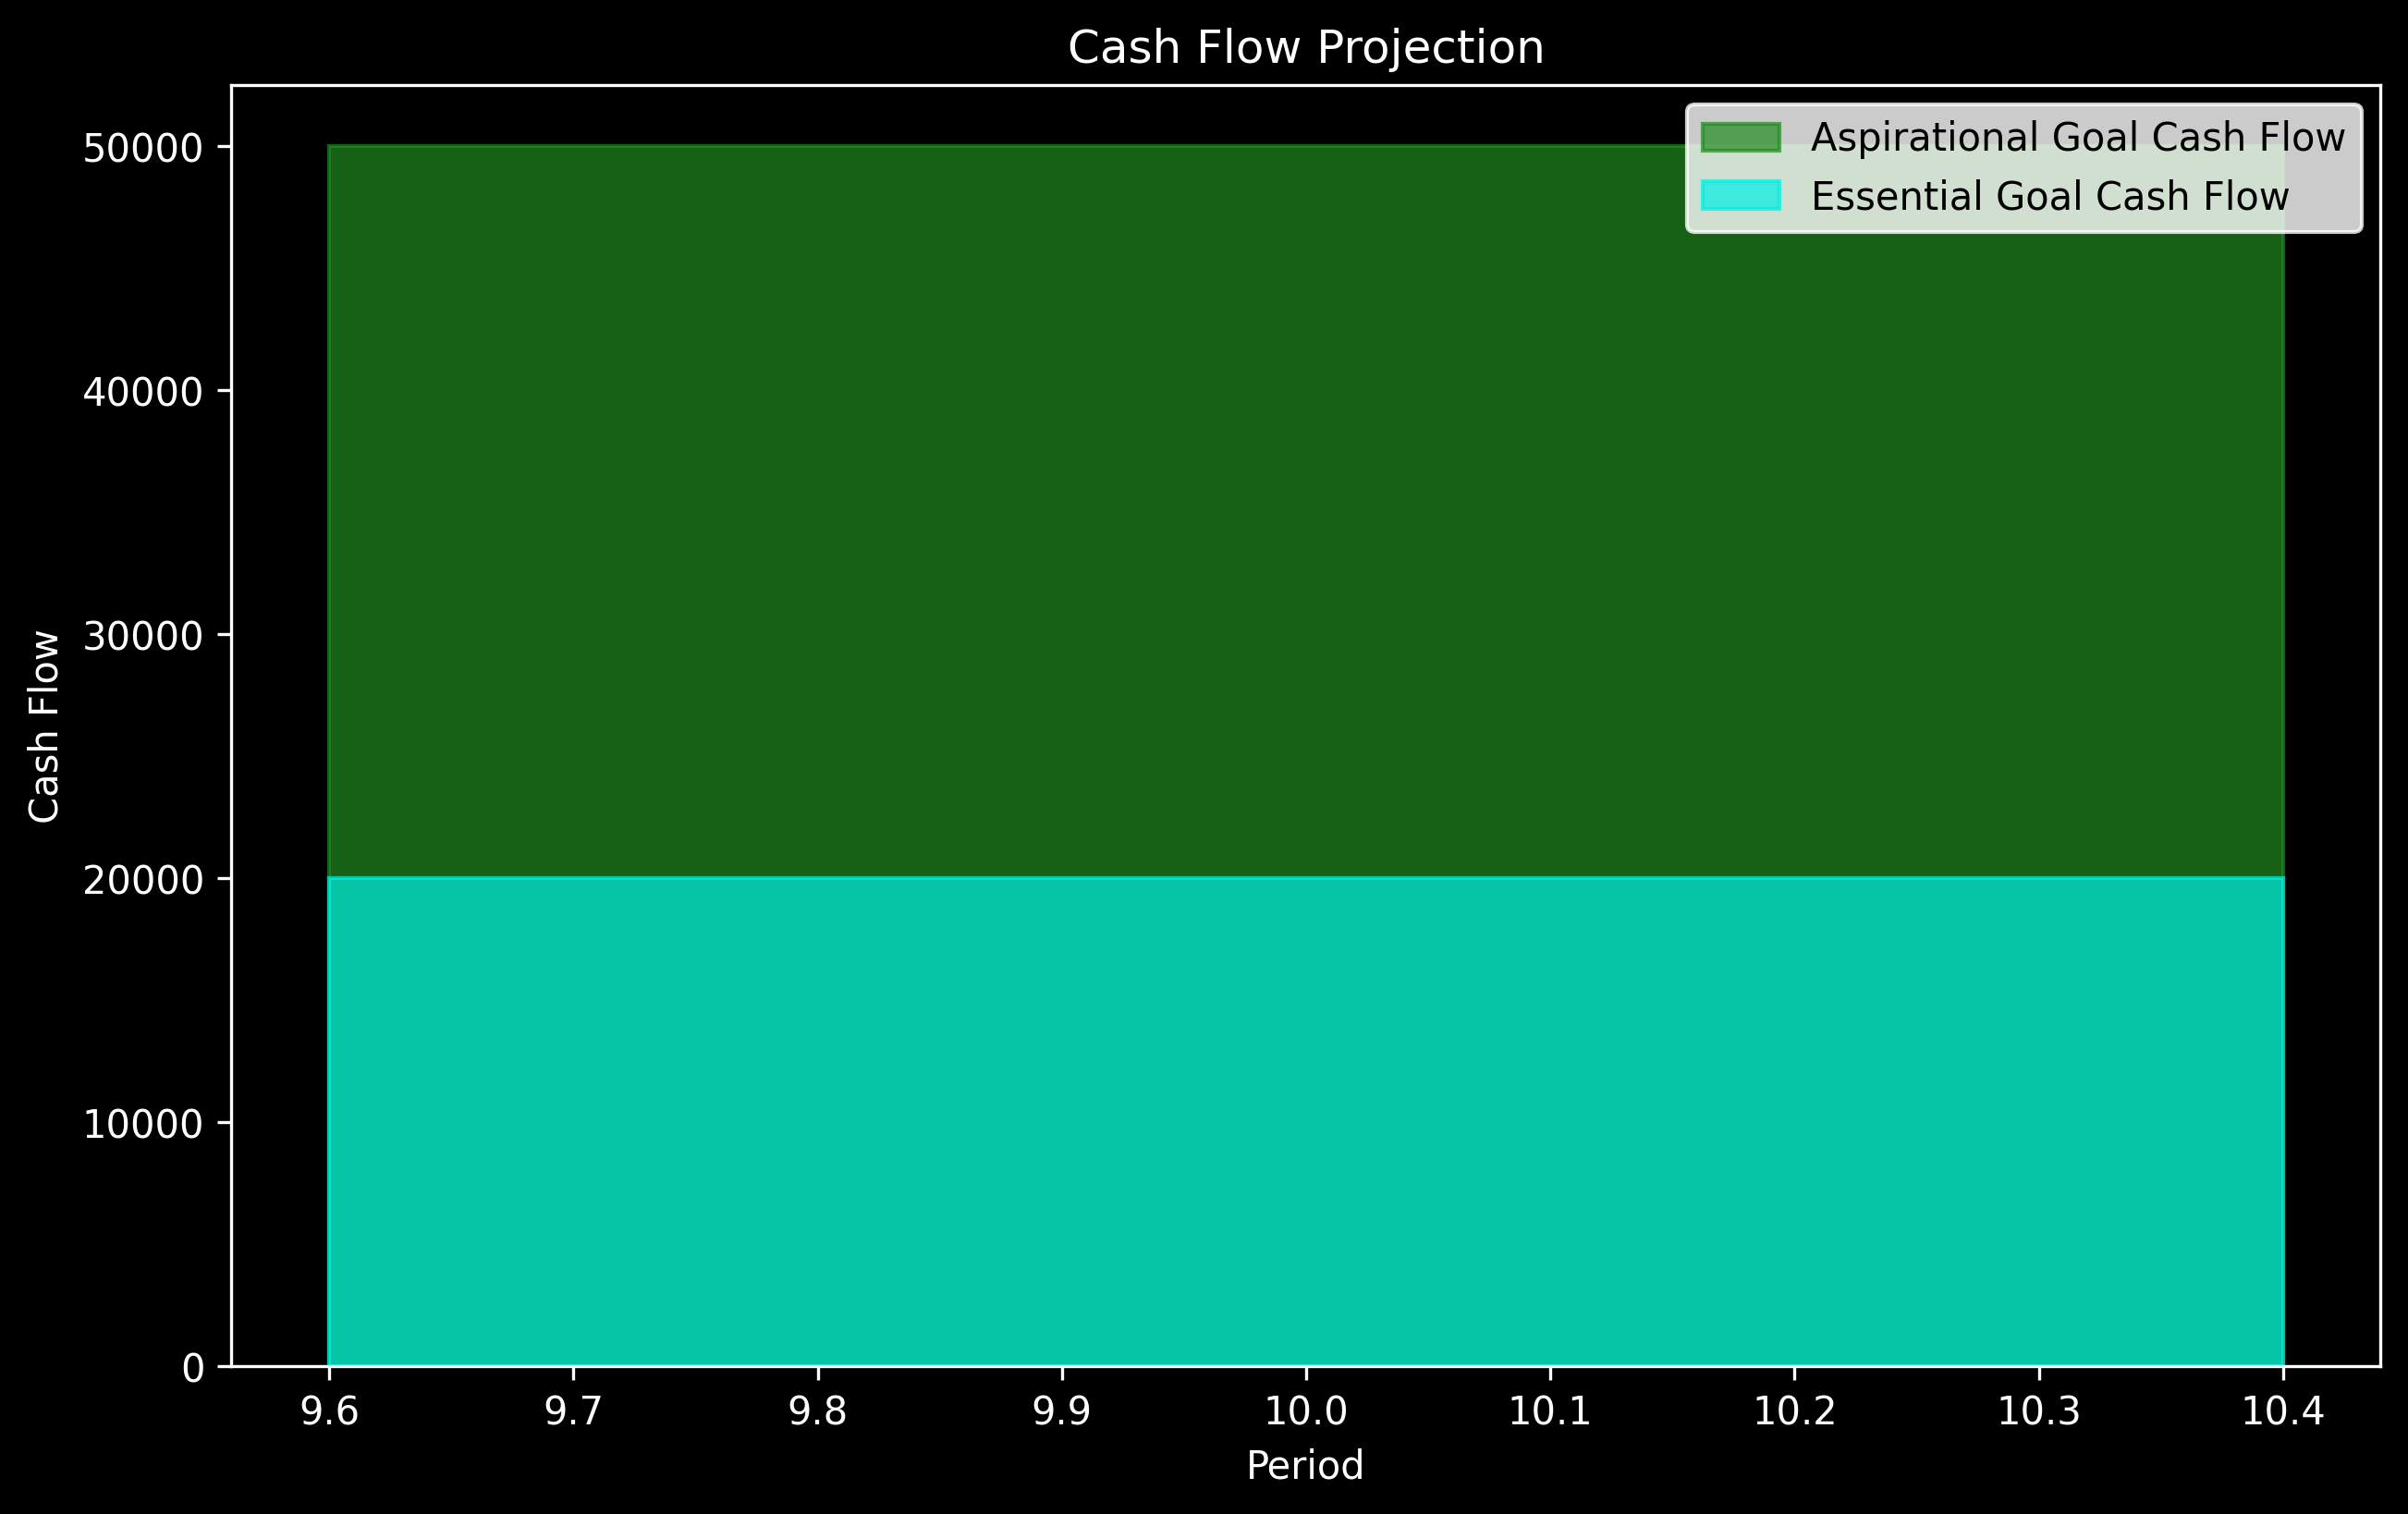

In [7]:
# Extract relevant columns
x_values = df.index  # Time (Period)
y1_values = df.iloc[:, 0]  # Pure_Essential_Goal_Cash_Flow
y2_values = df.iloc[:, 1]  # Pure_Aspirational_Goal_Cash_Flow

# Define colors
background_color = "black"
bar_color_essential = "#00EFE4"  # Sword-like blue
bar_color_aspirational = (34/255, 139/255, 34/255)

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6), dpi = 300)
fig.patch.set_facecolor(background_color)  # Set background

# Plot bars
ax.bar(x_values, y2_values, color=bar_color_aspirational, label="Aspirational Goal Cash Flow", alpha=0.7, edgecolor = bar_color_aspirational)
ax.bar(x_values, y1_values, color=bar_color_essential, label="Essential Goal Cash Flow", edgecolor = bar_color_essential, alpha = 0.7)


# Customizations
ax.set_facecolor(background_color)
ax.spines["bottom"].set_color("white")
ax.spines["top"].set_color("white")
ax.spines["right"].set_color("white")
ax.spines["left"].set_color("white")
ax.tick_params(colors="white")
ax.set_xlabel("Period", color="white")
ax.set_ylabel("Cash Flow", color="white")
ax.set_title("Cash Flow Projection", color="white")
ax.legend(facecolor="white", edgecolor="white")

# Show plot
plt.show()


Now we know cash flows that the client needs. Hence, we can simulate perfect retirement bond for him

In [8]:
simulated_market.calculate_perfect_retirement_bond(client)

Simulating scenarios: 100%|█████████████████| 1000/1000 [05:46<00:00,  2.88it/s]
/Users/aleksandrmikhailov/Desktop/GitHub_EDHEC/Retirement solution/Goal-Based-Investing/market_stochastic_simulation.py:305: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  retirement_bond_essential_p.loc[:, simulation_number] = result_essential[i]
/Users/aleksandrmikhailov/Desktop/GitHub_EDHEC/Retirement solution/Goal-Based-Investing/market_stochastic_simulation.py:306: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  retirement_bond_aspirational_p.loc[

Plot the market and the retirement bond index. If you would use M = 31, you would get full retirement bond price with ladder

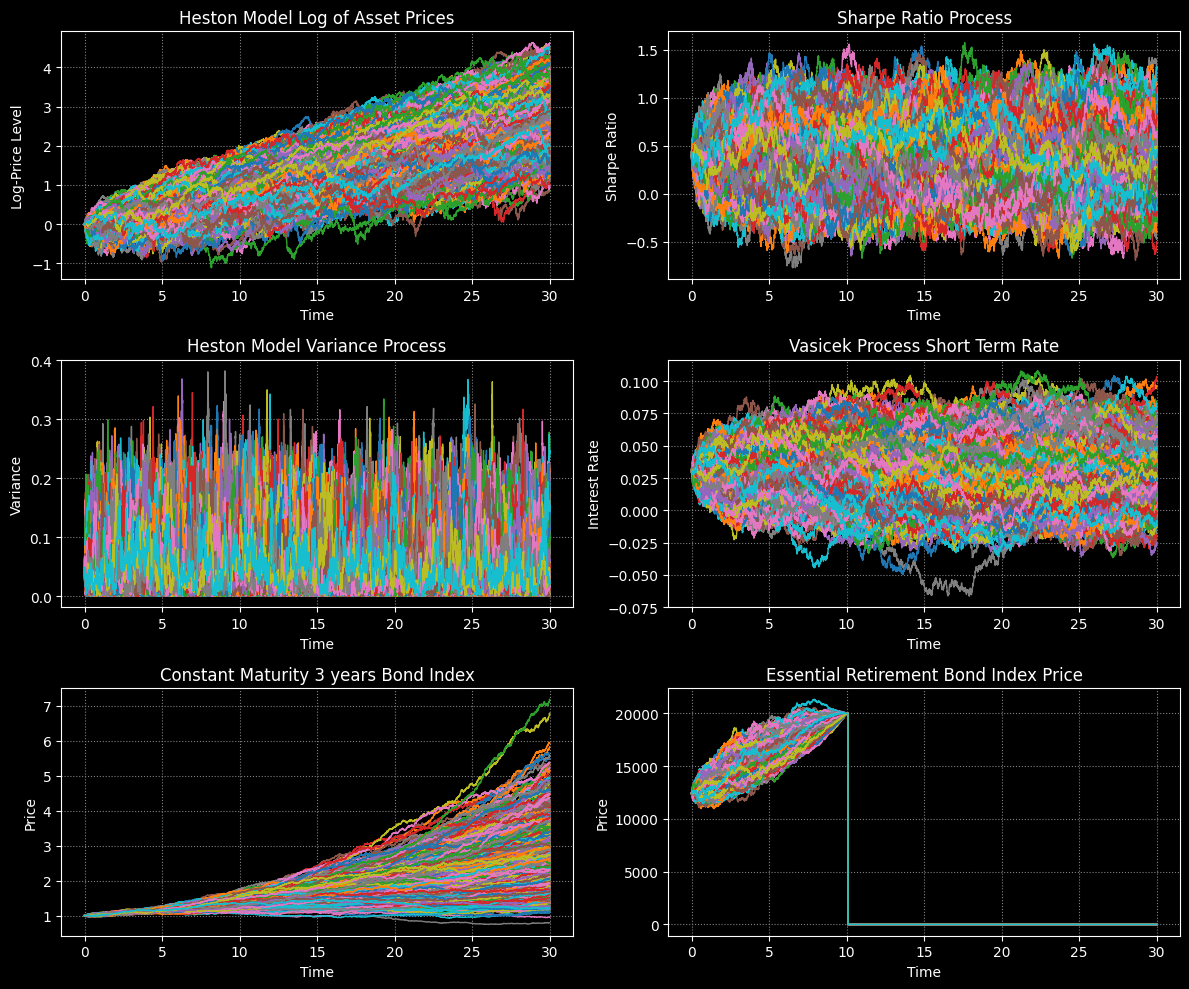

In [9]:
simulated_market.plot_market_simulation()

## Compare pure cash account with LDI solution

I want to invest some money now to get 20k in 10 years. What should I invest in?

We show that ZC bond is better than constant maturity bond index of 3 years

In [14]:
Initial_capital = simulated_market.retirement_bond_essential_p.loc[0,0]
Initial_capital

12434.840999226193

In [24]:
Final_sum_3y_bond_index = simulated_market.B_p.loc[10,:]*Initial_capital
Final_sum_ZC_bond = simulated_market.retirement_bond_essential_p.loc[10,:]

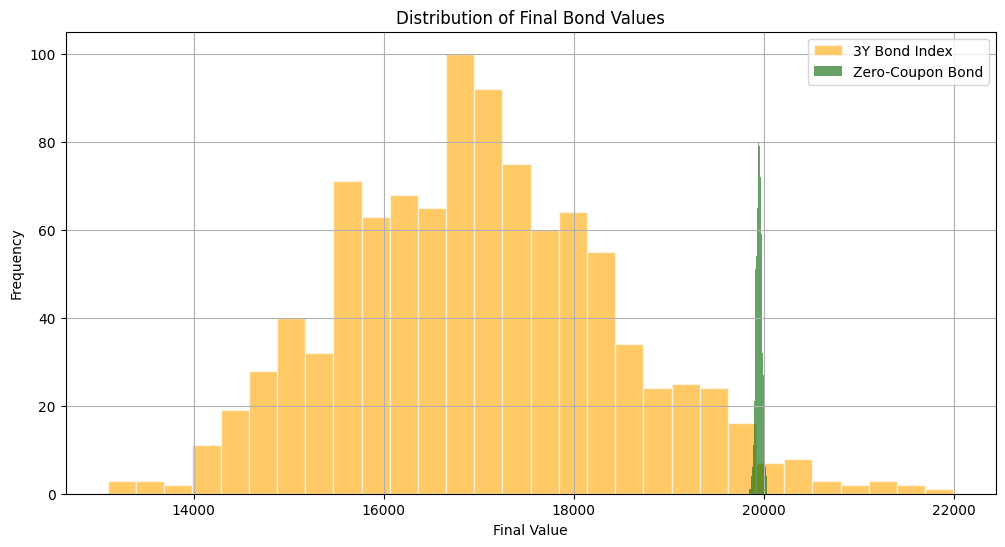

In [36]:

plt.figure(figsize=(12, 6))

# Histogram for 3y bond index
plt.hist(Final_sum_3y_bond_index, bins=30, alpha=0.6, label='3Y Bond Index',edgecolor='white', color = 'orange')

# Histogram for Zero-Coupon bond
plt.hist(Final_sum_ZC_bond, bins=30, alpha=0.6, label='Zero-Coupon Bond', color = 'darkgreen')

plt.xlabel('Final Value')
plt.ylabel('Frequency')
plt.title('Distribution of Final Bond Values')
plt.legend()
plt.grid(True)
plt.show()


Result:

You are likely to be underfunded with respect to final goal. You will not reach it! We can make you reach this goal

Risks:
- we assumed there is no inflation. In reality we will have to account for it
- we assumed there is easy access to ZC bond (or we can easily construct it). Currently this access is difficult. We can engineer this product though

To do:
- test the bond VS simple cash account that most of people use
- Test the ZC bond for different interest rate regimes